In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K
from tensorflow.image import ssim

import numpy as np
from matplotlib import pyplot as plt

# Separazione di immagini

Questo progetto ha l'obiettivo di separare un'immagine, ottenuta come somma di due immagini, nelle sue componenti originali.

Le due immagini di origine, img1 e img2, provengono da dataset diversi: MNIST e Fashion-MNIST, rispettivamente.

La rete neurale riceve in input l'immagine combinata (img1 + img2) e restituisce le predizioni (hat_img1 e hat_img2).

Le prestazioni vengono valutate utilizzando l'errore quadratico medio (MSE) tra le immagini predette e quelle di riferimento.

Entrambi i dataset (MNIST e Fashion-MNIST) sono in scala di grigi. Per semplicità, tutti i campioni vengono adattati alla risoluzione (32,32).

In [ ]:
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
print(np.shape(mnist_x_train))
(fashion_mnist_x_train, fashion_mnist_y_train), (fashion_mnist_x_test, fashion_mnist_y_test) = fashion_mnist.load_data()
#normnalize in and pad
mnist_x_train = np.pad(mnist_x_train,((0,0),(2,2),(2,2)))/255.
print(np.shape(mnist_x_train))
mnist_x_test = np.pad(mnist_x_test,((0,0),(2,2),(2,2)))/255.
fashion_mnist_x_train = np.pad(fashion_mnist_x_train,((0,0),(2,2),(2,2)))/255.
fashion_mnist_x_test = np.pad(fashion_mnist_x_test,((0,0),(2,2),(2,2)))/255.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 32, 32)


In [ ]:
print(np.shape(mnist_x_train))

(60000, 32, 32)


Qui di seguito un semplice generatore dei dati.

In [ ]:
def datagenerator(x1,x2,batchsize):
    n1 = x1.shape[0]
    n2 = x2.shape[0]
    while True:
        num1 = np.random.randint(0, n1, batchsize)
        num2 = np.random.randint(0, n2, batchsize)

        x_data = (x1[num1] + x2[num2]) / 2.0
        y_data = (x1[num1], x2[num2])

        yield x_data, y_data

Definiamo un generatore con batchsize=1 e visualizziamo qualche dato.

In [ ]:
onegen = datagenerator(mnist_x_test,fashion_mnist_x_test,1)

In [ ]:
def show_images(x,y1,y2):
    fig, ax = plt.subplots(1,3,figsize=(12,4))
    ax[0].imshow(x,cmap='gray')
    ax[0].title.set_text('Input')
    ax[0].axis('off')
    ax[1].imshow(y1,cmap='gray')
    ax[1].title.set_text('mnist')
    ax[1].axis('off')
    ax[2].imshow(y2,cmap='gray')
    ax[2].title.set_text('fashion_mnist')
    ax[2].axis('off')
    plt.show()

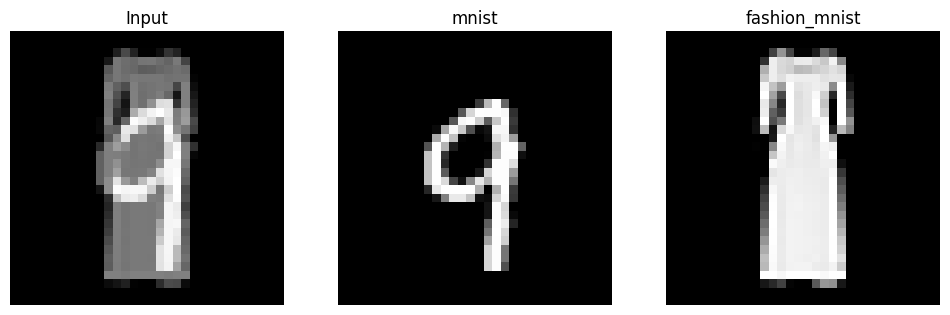

In [ ]:
x,(y1,y2)=next(onegen)
show_images(x[0],y1[0],y2[0])

# Valutazione delle prestazioni

Definiano un generatore di test con batchsize 5000.

In [ ]:
testgen = datagenerator(mnist_x_test,fashion_mnist_x_test,5000)

eval_samples_x, (eval_samples_y1, eval_sample2) = next(testgen)

Per raggiungere l'obiettivo del progetto è stata impiegata una U-Net. Questa rete neurale risulta particolarmente adatta perché, nonostante la sua architettura sia stata pensata prevalentemente per la segmentazione, il problema di separazione delle immagini è analogo: la rete deve assegnare a ciascun pixel il contributo corrispondente a img1 e img2.
La sua struttura Encoder-Decoder permette di estrarre le caratteristiche rilevanti dall'immagine combinata (img1 + img2), trasformandola in una rappresentazione compatta, e di utilizzare successivamente queste informazioni per ricostruire le immagini originali (hat_img1 e hat_img2), sfruttando le connessioni di skip per per distinguere le componenti sovrapposte.
Inoltre, l'utilizzo di BatchNormalization dopo ogni convoluzione migliora la stabilità durante l'addestramento. Nei layer di output è stata impiegata la funzione di attivazione sigmoid, che risulta appropriata per immagini normalizzate in scala di grigi.

In [ ]:
def down_block(inputs, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    # Encoder: blocco di Downsampling con BatchNormalization
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(inputs)
    conv = BatchNormalization()(conv)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    conv = BatchNormalization()(conv)
    pool = MaxPooling2D(pool_size=(2, 2))(conv)
    return conv, pool

def up_block(inputs, skip, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    # Decoder: blocco di Upsampling con BatchNormalization
    up = UpSampling2D(size=(2, 2))(inputs)
    concat = Concatenate()([up, skip])  # Concatenazione con il blocco di skip
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(concat)
    conv = BatchNormalization()(conv)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    conv = BatchNormalization()(conv)
    return conv

def ide_model(input_shape=(32, 32, 1)):
    inputs = Input(shape=input_shape)

    # Downsampling
    conv1, pool1 = down_block(inputs, 128)
    conv2, pool2 = down_block(pool1, 256)
    conv3, pool3 = down_block(pool2, 512)

    # Bottleneck
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)
    conv4 = BatchNormalization()(conv4)

    # Upsampling
    conv5 = up_block(conv4, conv3, 512)
    conv6 = up_block(conv5, conv2, 256)
    conv7 = up_block(conv6, conv1, 128)

    # Output Layers: le due immagini separate (hat_img1 e hat_img2)
    output1 = Conv2D(1, (1, 1), activation="sigmoid", padding="same")(conv7)  # hat_img1
    output2 = Conv2D(1, (1, 1), activation="sigmoid", padding="same")(conv7)  # hat_img2

    # Creazione del modello
    model = models.Model(inputs=inputs, outputs=[output1, output2], name="unet")

    return model

Qui di seguito la configurazione per l'addestramento del modello: viene utilizzato Adam come ottimizzatore e mean_squared_error come funzione di loss, coerentemente con l'obiettivo di minimizzare l'errore quadratico medio. Vengono inoltre impiegate due callback:

*   Early Stopping, che ferma l'addestramento se la loss non migliora per 4 epoche, rispristinando i pesi migliori;
*   Riduzione del Learning Rate: se la loss non migliora per 2 epoche, il learning rate viene dimezzato, migliorando la convergenza.

La batchsize scelta per i dati di addestramento è 32, e il numero 1875 del parametro steps_per_epoch deriva dal calcolo 60000/32, dove 60000 è la dimensione del training set. Questo garantisce che l'intero dataset venga "coperto" in un'epoca (o una porzione rappresentativa di esso, dato che il generatore estrae campioni casualmente).




In [ ]:
model = ide_model(input_shape=(32, 32, 1))

# Callback per fermare l'addestramento se la loss smette di ridursi
early_stopping = EarlyStopping(
    monitor='loss',
    patience=5,  # Numero di epoche senza miglioramenti prima di fermarsi
    restore_best_weights=True,  # Ripristina i migliori pesi trovati
    verbose=1
)

# Callback per ridurre il learning rate quando la loss si stabilizza
reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,  # Riduce il learning rate della metà
    patience=3,  # Numero di epoche senza miglioramenti prima di ridurre il LR
    min_lr=1e-6,  # Limite minimo per il learning rate
    verbose=1
)

def combined_loss(y_true, y_pred):
    mse = K.mean(K.square(y_true - y_pred))  # Mean Squared Error
    ssim_loss = K.mean(1 - ssim(y_true, y_pred, max_val=1.0))  # SSIM Loss
    return mse + 0.5 * ssim_loss  # Ponderazione tra le due

# Compilazione del modello con la loss function MSE
model.compile(optimizer="adam", loss=combined_loss)

# Creazione del generatore per i dati di addestramento
traingen = datagenerator(mnist_x_train, fashion_mnist_x_train, batchsize=32)

# Addestramento del modello
model.fit(traingen, steps_per_epoch=1875, epochs=40, callbacks=[early_stopping, reduce_lr])

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 225s 105ms/step - conv2d_14_loss: 0.0823 - conv2d_15_loss: 0.0473 - loss: 0.1296 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 198s 105ms/step - conv2d_14_loss: 0.0096 - conv2d_15_loss: 0.0092 - loss: 0.0189 - learning_rate: 0.0010
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 197s 105ms/step - conv2d_14_loss: 0.0078 - conv2d_15_loss: 0.0073 - loss: 0.0151 - learning_rate: 0.0010
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 197s 105ms/step - conv2d_14_loss: 0.0065 - conv2d_15_loss: 0.0060 - loss: 0.0125 - learning_rate: 0.0010
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 198s 105ms/step - conv2d_14_loss: 0.0059 - conv2d_15_loss: 0.0054 - loss: 0.0113 - learning_rate: 0.0010
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 198s 106ms/step - conv2d_14_loss: 0.0056 - conv2d_15_loss: 0.0049 - loss: 0.0105 - learning_rate: 0.0010
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 197s 105ms/step - conv2d_14_loss: 0.0051 - conv2d_15_loss: 0.0046 - loss: 0.

In [ ]:
# Mostra alcuni esempi di input e output del modello.
def show_predictions(x, y1, y2, pred1, pred2):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    axes[0].imshow(x[0], cmap='gray')  # Immagine combinata (input)
    axes[0].set_title("Immagine Combinata")
    axes[0].axis('off')

    axes[1].imshow(y1[0, ..., 0], cmap='gray')  # Ground Truth Immagine 1
    axes[1].set_title("Ground Truth 1")
    axes[1].axis('off')

    axes[2].imshow(y2[0, ..., 0], cmap='gray')  # Ground Truth Immagine 2
    axes[2].set_title("Ground Truth 2")
    axes[2].axis('off')

    axes[3].imshow(pred1[0, ..., 0], cmap='gray')  # Predizione 1
    axes[3].set_title("Predizione 1")
    axes[3].axis('off')

    axes[4].imshow(pred2[0, ..., 0], cmap='gray')  # Predizione 2
    axes[4].set_title("Predizione 2")
    axes[4].axis('off')

    plt.show()

In [ ]:
def eval_model(model):
  x, (y1,y2) = next(testgen)

  pred1, pred2 = model.predict(x)
  y1 = np.expand_dims(y1,axis=-1)
  y2 = np.expand_dims(y2,axis=-1)

  show_predictions(x, y1, y2, pred1, pred2) # viene mostrato un esempio ogni volta che eval_model viene eseguita

  return ((np.mean((pred1-y1)**2) + np.mean((pred2-y2)**2)) / 2)


157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step


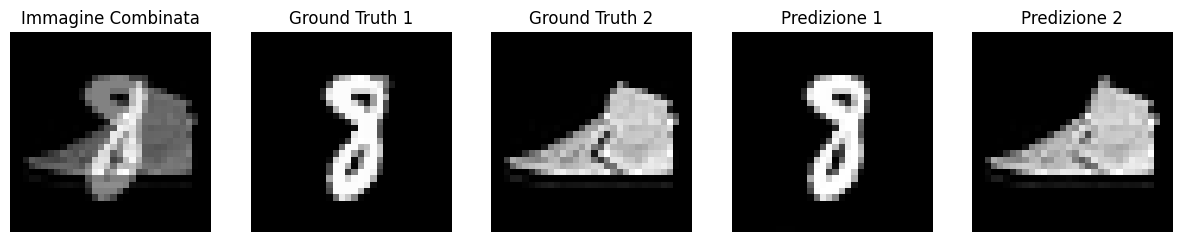

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


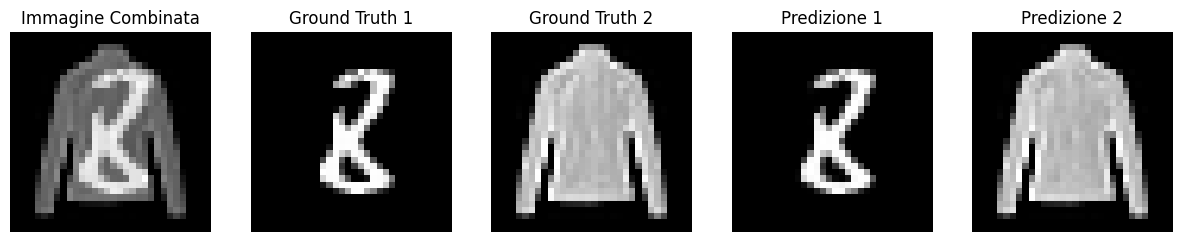

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


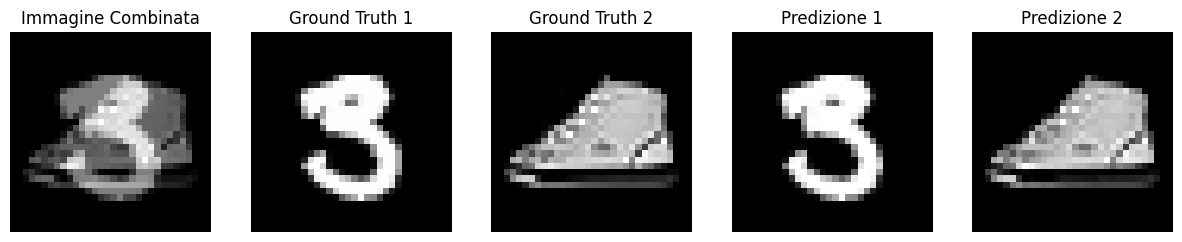

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


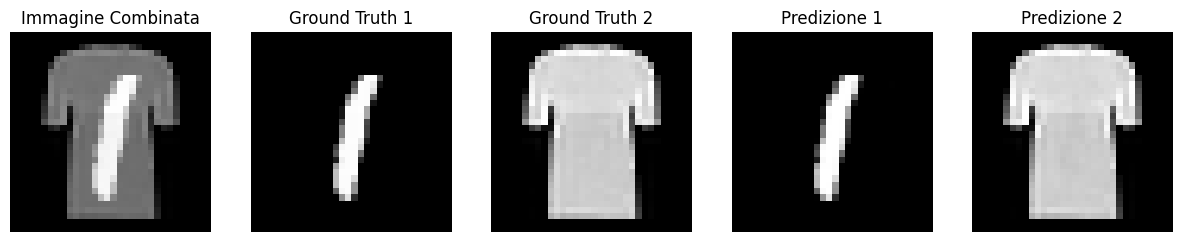

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


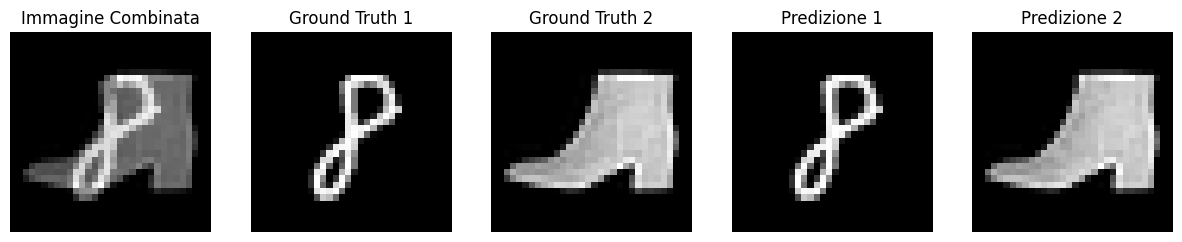

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


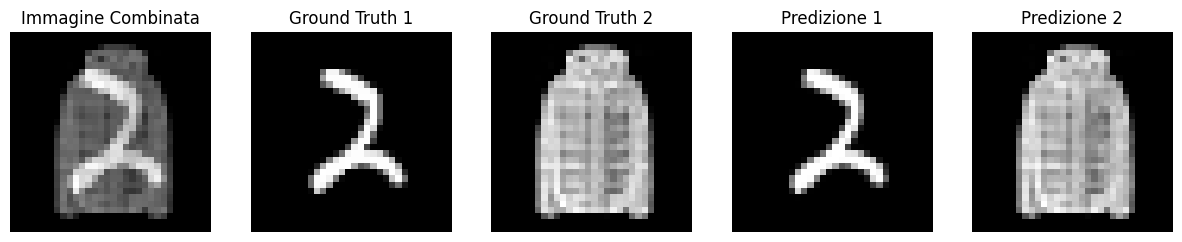

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step


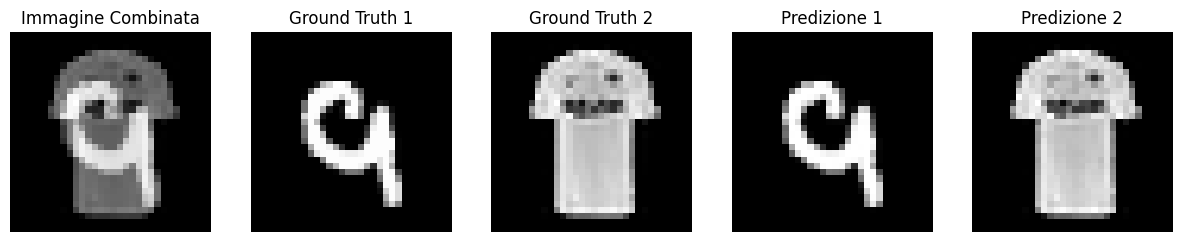

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


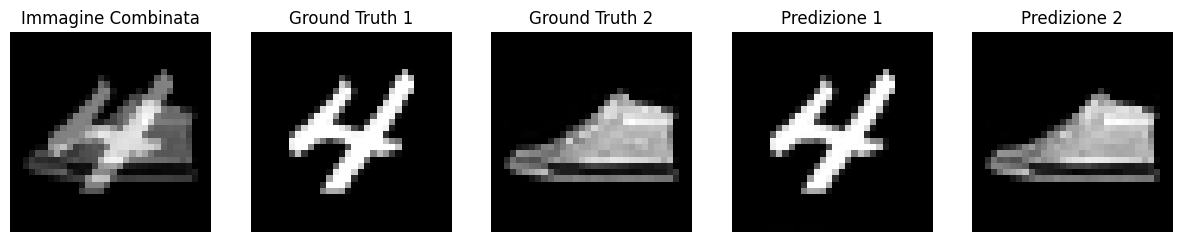

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


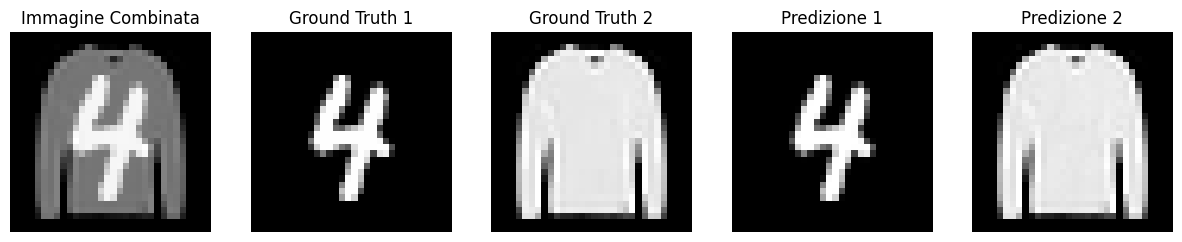

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


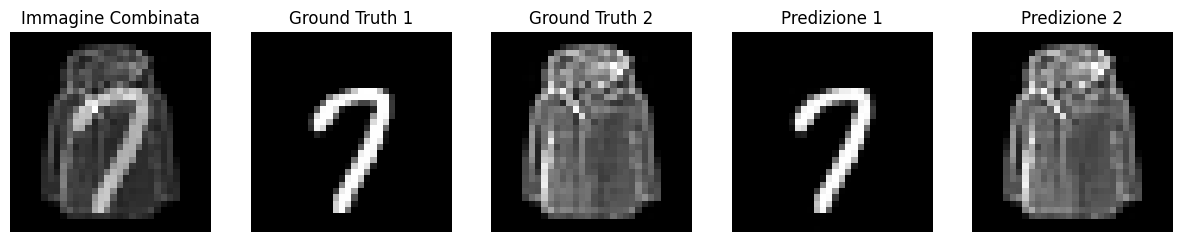

mse =  0.00041332301307738846
standard deviation =  7.208330365928753e-06


In [ ]:
repeat_eval = 10
eval_results = []
for i in range(repeat_eval):
  eval_results.append(eval_model(model))
print("mse = ", np.mean(eval_results))
print("standard deviation = ", np.std(eval_results))